In [2]:
import imports
import split, model, weights, balance_train

In [3]:
import numpy as np

X = np.load("input/X.npy")
y = np.load("input/y.npy")

print(X.shape)  # (N, 90, 1)
print(y.shape)  # (N,)


(15272, 90, 1)
(15272,)


In [4]:
X_train, X_val, X_test, y_train, y_val, y_test = split.stratified_split(X, y)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)


Train: (9773, 90, 1) (9773,)
Val:   (2444, 90, 1) (2444,)
Test:  (3055, 90, 1) (3055,)


In [16]:
print("Train class distribution:", np.bincount(y_train.astype(int)))
print("Val class distribution:", np.bincount(y_val.astype(int)))
print("Test class distribution:", np.bincount(y_test.astype(int)))


Train class distribution: [8149 1624]
Val class distribution: [2038  406]
Test class distribution: [2548  507]


In [17]:
print(y_train.shape)

(9773,)


In [18]:
import importlib
import model
importlib.reload(model)

<module 'model' from '/home/jupyter-22wh1a12a2/major_project/DNA/model.py'>

In [19]:
from model import build_model, compile_model

model1 = build_model()
model1 = compile_model(model1)

model1.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 90, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 90, 32)    │        128 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 90, 32)    │        192 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 90, 32)    │        256 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 90, 96)    │          0 │ conv1d_6[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_7[0][0],   │
│                     │                   │            │ conv1d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 45, 96)    │          0 │ concatenate_2[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     41,216 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      4,160 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 46,017 (179.75 KB)

 Trainable params: 46,017 (179.75 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
X_balanced, y_balanced = balance_train.balance_data(X_train, y_train, positive_factor=3, random_state=42)

In [21]:
print(y_train.dtype)
print(np.unique(y_train))

float32
[0. 1.]


In [22]:
print(np.bincount(y_train.astype(int)))
print(np.bincount(y_balanced.astype(int)))

[8149 1624]
[4872 4872]


In [23]:
history = balance_train.train_model(model1, X_balanced, y_balanced, X_val, y_val)

Epoch 1/200
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.6867 - pr_auc: 0.5314 - precision_2: 0.5241 - recall_2: 0.4968 - roc_auc: 0.5433
Epoch 1: val_pr_auc improved from None to 0.45943, saving model to output/rna_balanced.keras

Epoch 1: finished saving model to output/rna_balanced.keras
305/305 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - loss: 0.6616 - pr_auc: 0.6287 - precision_2: 0.5891 - recall_2: 0.5950 - roc_auc: 0.6379 - val_loss: 0.5487 - val_pr_auc: 0.4594 - val_precision_2: 0.3214 - val_recall_2: 0.7931 - val_roc_auc: 0.8028 - learning_rate: 0.0010
Epoch 2/200
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.5630 - pr_auc: 0.7704 - precision_2: 0.7059 - recall_2: 0.7346 - roc_auc: 0.7810
Epoch 2: val_pr_auc improved from 0.45943 to 0.58997, saving model to output/rna_balanced.keras

Epoch 2: finished saving model to output/rna_balanced.keras
305/305 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - loss: 0.5347 - pr_auc: 0.8091 - precision_2: 0.7339 - recall_2: 0.7319 - roc_auc: 0.8

In [24]:
results = model1.evaluate(X_test, y_test, verbose=0, return_dict=True)
print(results)

{'loss': 0.42899221181869507, 'pr_auc': 0.638556718826294, 'precision_2': 0.44147157669067383, 'recall_2': 0.7810651063919067, 'roc_auc': 0.8790674805641174}


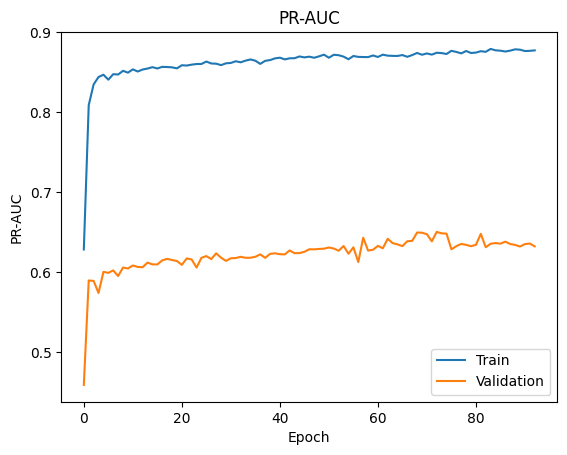

In [25]:
import matplotlib.pyplot as plt

plt.plot(history.history['pr_auc'])
plt.plot(history.history['val_pr_auc'])
plt.title('PR-AUC')
plt.xlabel('Epoch')
plt.ylabel('PR-AUC')
plt.legend(['Train', 'Validation'])
plt.show()


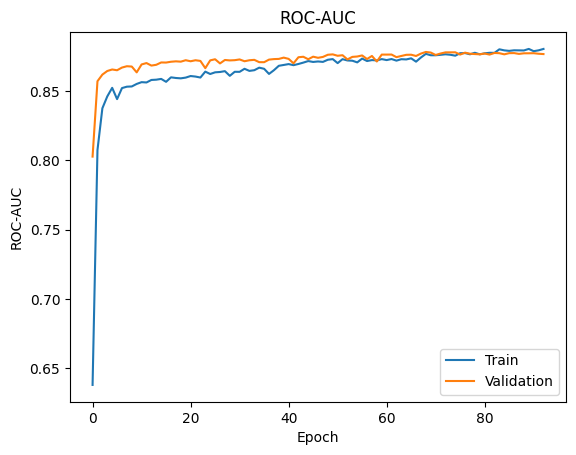

In [26]:
plt.plot(history.history['roc_auc'])
plt.plot(history.history['val_roc_auc'])
plt.title('ROC-AUC')
plt.xlabel('Epoch')
plt.ylabel('ROC-AUC')
plt.legend(['Train', 'Validation'])
plt.show()


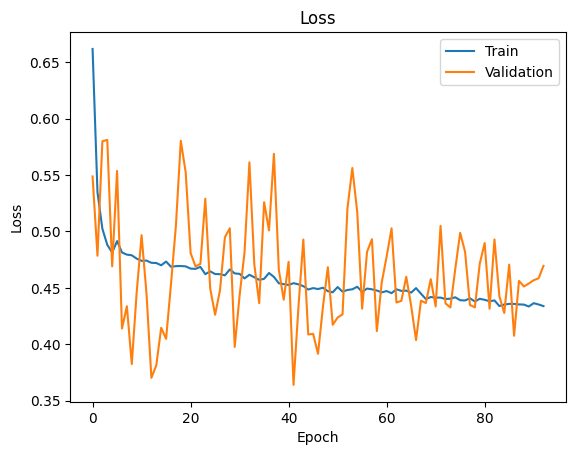

In [27]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()


In [6]:
from tensorflow.keras.models import load_model
import numpy as np

model1 = load_model("output/dna_balanced.keras", compile=False)
predictions = model1.predict(X_test)  
predictions = predictions.flatten()    

predicted_labels = (predictions > 0.5).astype(int)
y_true = y_test.flatten().astype(int)

accuracy = (predicted_labels == y_true).mean()
print("Test Accuracy:", accuracy)

96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
Test Accuracy: 0.7996726677577741
